In [82]:
import warnings
warnings.filterwarnings(action='ignore') 

import datetime
import pandas as pd
import numpy as np
import csv
import folium
from folium.plugins import HeatMap 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
import scipy as sp
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.formula.api as smf
from dateutil.relativedelta import relativedelta
# import setuptools.dist
from yellowbrick.cluster import KElbowVisualizer
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

In [83]:
welfare = pd.read_csv('../../data/Koweps_hpwc14_2019_beta2.csv', encoding="utf-8") 
welfare.head(3)

,h14_id,h14_ind,h14_sn,h14_merkey,h_new,h14_cobf,p14_wsc,p14_wsl,p14_wgc,p14_wgl,...,wc14_64,wc14_65,wc14_5aq4,wc14_5aq5,wc14_5aq6,h14_pers_income1,h14_pers_income2,h14_pers_income3,h14_pers_income4,h14_pers_income5
0,2.0,1.0,1.0,20101.0,0.0,NaN,0.291589,0.291589,1307.764781,1307.764781,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,3.0,1.0,1.0,30101.0,0.0,NaN,0.419753,0.419753,1882.570960,1882.570960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,4.0,1.0,1.0,40101.0,0.0,NaN,0.265263,0.265980,1189.691668,1192.908537,...,NaN,NaN,NaN,NaN,NaN,NaN,1284.0,NaN,0.0,NaN


In [84]:
welfare.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14418 entries, 0 to 14417
Columns: 830 entries, h14_id to h14_pers_income5
dtypes: float64(826), object(4)
memory usage: 91.3+ MB


In [85]:
## 항목 이름 변경하기

welfare = welfare.rename(columns = {'h14_g3'     : 'gender',         #  성별
                                    'h14_g4'     : 'birth',          #  태어난 년도
                                    'h14_g10'    : 'marriage_type',  #  혼인 상태
                                    'h14_g11'    : 'religion',       #  종교 
                                    'p1402_8aq1' : 'income',         #  급여 
                                    'h14_eco9'   : 'code_job',       #  직업 코드
                                    'h14_reg7'   : 'code_region'})   #  지역 코드

In [86]:
welfare = welfare[['gender','birth','marriage_type',  'religion', 'income','code_job', 'code_region']]
welfare

,gender,birth,marriage_type,religion,income,code_job,code_region
0,2.0,1945.0,2.0,1.0,NaN,NaN,1.0
1,1.0,1948.0,2.0,2.0,NaN,NaN,1.0
2,1.0,1942.0,3.0,1.0,107.0,762.0,1.0
3,1.0,1962.0,1.0,1.0,192.0,855.0,1.0
4,2.0,1963.0,1.0,1.0,NaN,NaN,1.0
...,...,...,...,...,...,...,...
14413,2.0,1967.0,1.0,1.0,NaN,NaN,5.0
14414,2.0,1992.0,5.0,1.0,NaN,NaN,5.0
14415,1.0,1995.0,5.0,1.0,NaN,910.0,5.0
14416,2.0,1998.0,5.0,1.0,200.0,246.0,5.0


## 성별에 따른 급여 차이

### 성별 변수 검토 및 전처리 하기

In [87]:
welfare['gender'].dtypes    # 변수 타입 출력

dtype('float64')

In [88]:
welfare['gender'].value_counts()    # 빈도 구하기

gender
2.0    7913
1.0    6505
Name: count, dtype: int64

In [89]:
# 성별이 1 또는 2가 아닌 데이터를 찾아서 결측치로 처리
welfare['gender'] = np.where(welfare['gender'] == 9, np.nan, welfare['gender'])
welfare['gender'].isna().sum()

np.int64(0)

In [90]:
# 성별 값을 'male'과 'female'로 변경
welfare['gender'] = np.where(welfare['gender'] == 1, 'male', 'female')
welfare['gender'].value_counts()

gender
female    7913
male      6505
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

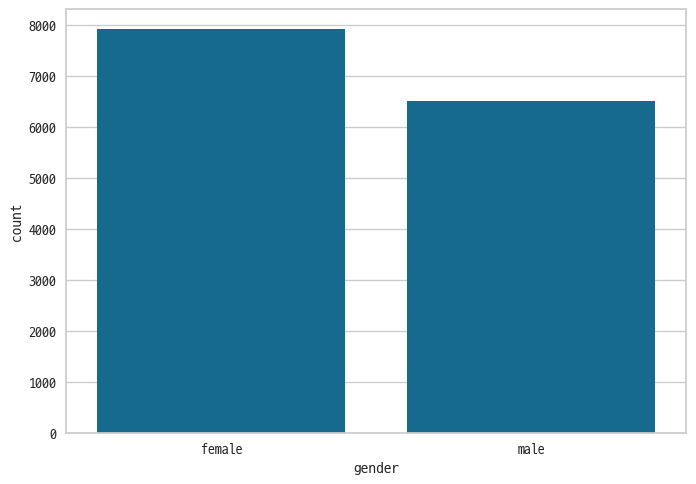

In [91]:
# 빈도 막대 그래프 그리기
sns.countplot(data=welfare, x='gender')

### 급여 변수 검토 및 전처리 하기

In [92]:
welfare['income'].dtypes

dtype('float64')

In [93]:
welfare['income'].describe()

count    4534.000000
mean      268.455007
std       198.021206
min         0.000000
25%       150.000000
50%       220.000000
75%       345.750000
max      1892.000000
Name: income, dtype: float64

In [94]:
welfare['income'] = np.where(welfare['income'] == 9999, np.nan, welfare['income'])
welfare['income'].isna().sum()

np.int64(9884)

<Axes: xlabel='income', ylabel='Count'>

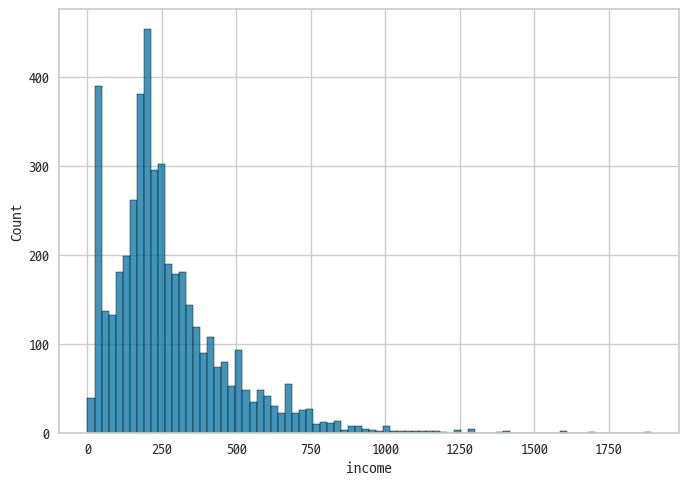

In [95]:
sns.histplot(data = welfare, x = 'income')

### 성별에 따른 급여 차이

In [96]:
## 성별 급여 평균
gender_income = welfare.dropna(subset = 'income').groupby('gender', as_index=False).agg(mean_income = ('income', 'mean'))
gender_income

,gender,mean_income
0,female,186.293096
1,male,349.037571


<Axes: xlabel='gender', ylabel='mean_income'>

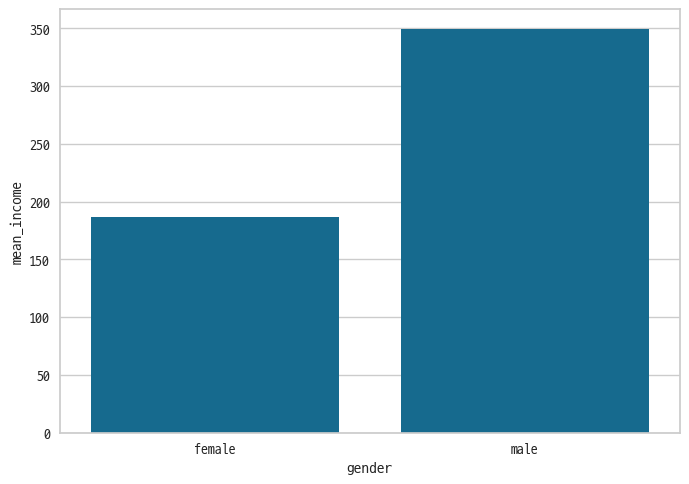

In [97]:
sns.barplot(data=gender_income, x='gender', y='mean_income')

## 나이와 급여의 관계_ 가장 많이 급여를 받는 나이는 언제일까?

출생년도 변수 검토 및 전처리

In [98]:
welfare['birth'].dtype

dtype('float64')

In [99]:
welfare['birth'].describe()

count    14418.000000
mean      1969.280205
std         24.402250
min       1907.000000
25%       1948.000000
50%       1968.000000
75%       1990.000000
max       2018.000000
Name: birth, dtype: float64

<Axes: xlabel='birth', ylabel='Count'>

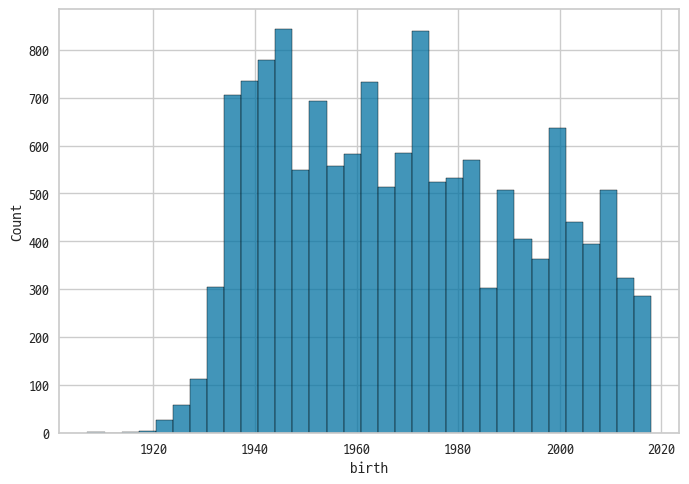

In [100]:
sns.histplot(data=welfare, x='birth')

In [101]:
welfare['birth'] = np.where(welfare['birth'] == 9999, np.nan, welfare['birth'])
welfare['birth'].isna().sum()

np.int64(0)

In [102]:
## '나이' 항목을 추가하고 나이 계산(2019년 데이터)

welfare = welfare.assign(age = 2019 - welfare['birth'])
# welfare['age'] = 2019 - welfare['birth']
welfare

,gender,birth,marriage_type,religion,income,code_job,code_region,age
0,female,1945.0,2.0,1.0,NaN,NaN,1.0,74.0
1,male,1948.0,2.0,2.0,NaN,NaN,1.0,71.0
2,male,1942.0,3.0,1.0,107.0,762.0,1.0,77.0
3,male,1962.0,1.0,1.0,192.0,855.0,1.0,57.0
4,female,1963.0,1.0,1.0,NaN,NaN,1.0,56.0
...,...,...,...,...,...,...,...,...
14413,female,1967.0,1.0,1.0,NaN,NaN,5.0,52.0
14414,female,1992.0,5.0,1.0,NaN,NaN,5.0,27.0
14415,male,1995.0,5.0,1.0,NaN,910.0,5.0,24.0
14416,female,1998.0,5.0,1.0,200.0,246.0,5.0,21.0


In [103]:
welfare['age'].describe()

count    14418.000000
mean        49.719795
std         24.402250
min          1.000000
25%         29.000000
50%         51.000000
75%         71.000000
max        112.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

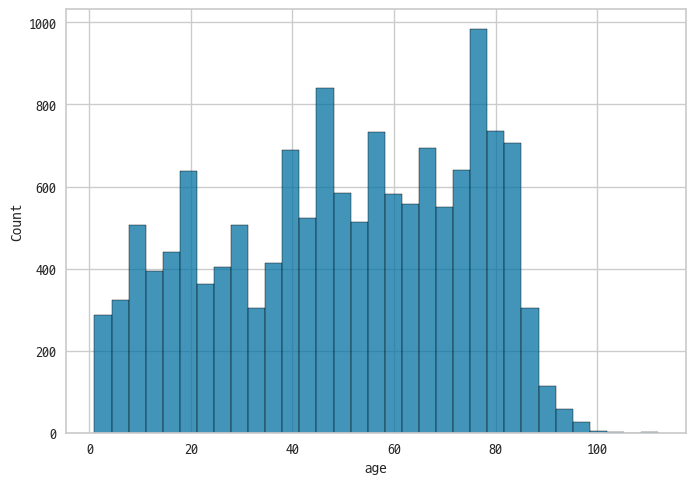

In [104]:
sns.histplot(data=welfare, x='age')

### 나이와 급여의 관계

In [105]:
age_income = welfare.dropna(subset = 'income').groupby('age').agg(mean_income = ('income', 'mean'))
age_income

,mean_income
age,
18.0,162.000000
19.0,121.333333
20.0,136.400000
21.0,123.666667
22.0,179.676471
...,...
87.0,27.000000
88.0,27.000000
89.0,27.000000


<Axes: xlabel='age', ylabel='mean_income'>

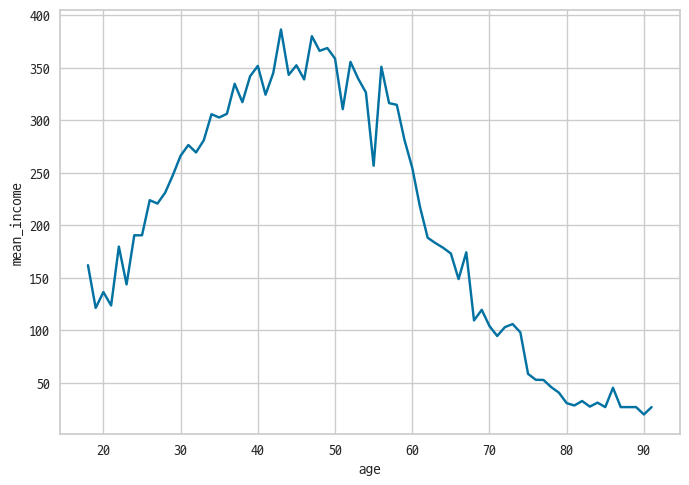

In [106]:
sns.lineplot(data = age_income, x='age', y='mean_income')

## 연령대에 따른 급여 차이

### 파생변수 만들기 _ 연령대

In [107]:
welfare['age'].head()

0    74.0
1    71.0
2    77.0
3    57.0
4    56.0
Name: age, dtype: float64

In [108]:
welfare = welfare.assign(ageg = np.where(welfare['age'] < 30, 'young', np.where(welfare['age'] < 60, 'middle', 'old')))
welfare['ageg'].value_counts()

ageg
old       5743
middle    5066
young     3609
Name: count, dtype: int64

<Axes: xlabel='ageg', ylabel='count'>

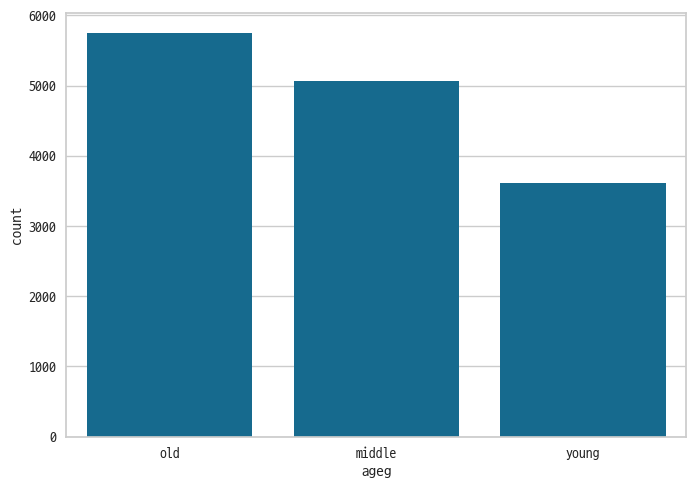

In [109]:
sns.countplot(data=welfare, x = 'ageg')

### 연령층에 따른 급여 차이

In [110]:
ageg_income = welfare.dropna(subset='income').groupby('ageg', as_index=False).agg(mean_income = ('income', 'mean'))
ageg_income

,ageg,mean_income
0,middle,329.737610
1,old,126.260302
2,young,202.595278


<Axes: xlabel='ageg', ylabel='mean_income'>

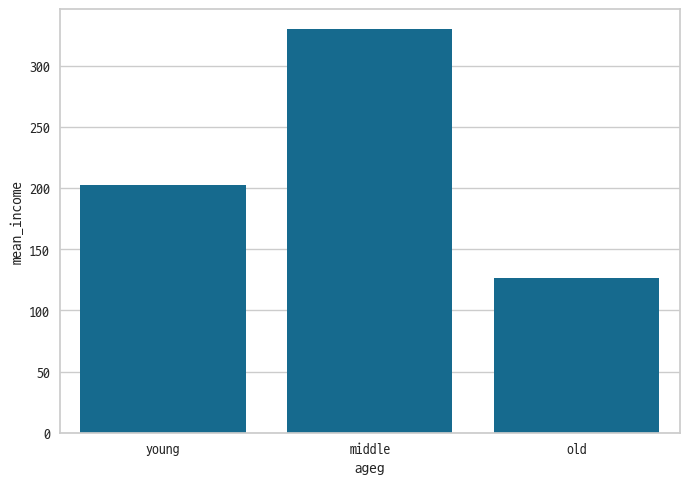

In [111]:
sns.barplot(data=ageg_income, x='ageg', y='mean_income', order=['young', 'middle', 'old'])

## 연령층 및 성별급여 차이 _ 성별 급여차이는 연령층별로 다를까?

In [112]:
gender_income = welfare.dropna(subset='income').groupby(['ageg', 'gender'], as_index=False).agg(mean_income = ('income', 'mean'))
gender_income

,ageg,gender,mean_income
0,middle,female,229.026677
1,middle,male,410.602203
2,old,female,84.324653
3,old,male,183.909308
4,young,female,193.764706
5,young,male,215.953390


<Axes: xlabel='ageg', ylabel='mean_income'>

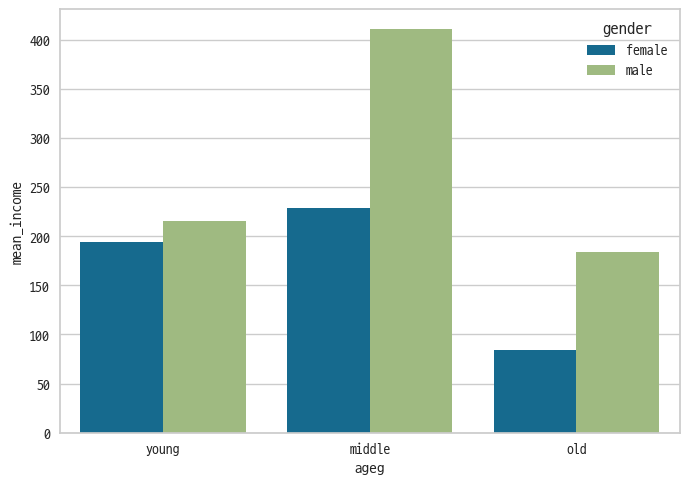

In [113]:
sns.barplot(data=gender_income, x='ageg', y='mean_income', hue='gender', order=['young', 'middle', 'old'])

In [114]:
gender_age = welfare.dropna(subset='income').groupby(['age', 'gender'], as_index=False).agg(mean_income = ('income', 'mean'))
gender_age.head()

,age,gender,mean_income
0,18.0,male,162.000000
1,19.0,female,87.666667
2,19.0,male,155.000000
3,20.0,female,124.000000
4,20.0,male,186.000000


<Axes: xlabel='age', ylabel='mean_income'>

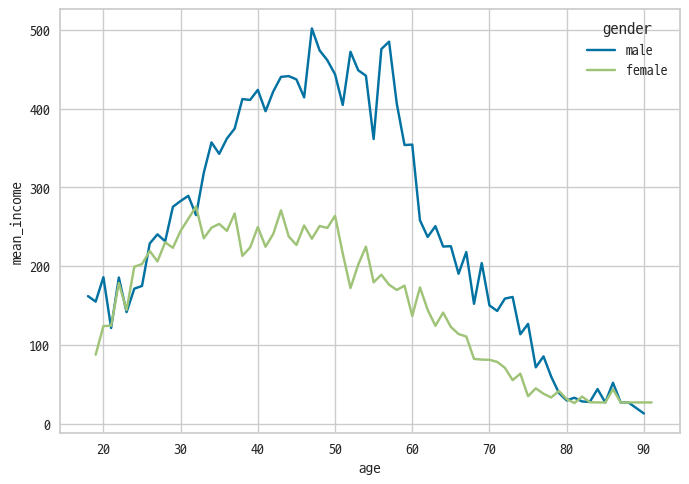

In [115]:
sns.lineplot(data=gender_age, x='age', y='mean_income', hue='gender')

In [116]:
welfare

,gender,birth,marriage_type,religion,income,code_job,code_region,age,ageg
0,female,1945.0,2.0,1.0,NaN,NaN,1.0,74.0,old
1,male,1948.0,2.0,2.0,NaN,NaN,1.0,71.0,old
2,male,1942.0,3.0,1.0,107.0,762.0,1.0,77.0,old
3,male,1962.0,1.0,1.0,192.0,855.0,1.0,57.0,middle
4,female,1963.0,1.0,1.0,NaN,NaN,1.0,56.0,middle
...,...,...,...,...,...,...,...,...,...
14413,female,1967.0,1.0,1.0,NaN,NaN,5.0,52.0,middle
14414,female,1992.0,5.0,1.0,NaN,NaN,5.0,27.0,young
14415,male,1995.0,5.0,1.0,NaN,910.0,5.0,24.0,young
14416,female,1998.0,5.0,1.0,200.0,246.0,5.0,21.0,young


### 직종별 급여 차이 - 어떤 직종이 급여가 가장 많을까?

In [117]:
welfare['code_job'].dtypes

dtype('float64')

In [118]:
## 직종코드 빈도
welfare['code_job'].value_counts()

code_job
611.0    962
941.0    391
521.0    354
312.0    275
873.0    236
        ... 
784.0      2
122.0      2
861.0      1
423.0      1
872.0      1
Name: count, Length: 150, dtype: int64

In [119]:
## 직종 코드 파일 불러오기
list_job = pd.read_excel('../../data/Koweps_Codebook_2019.xlsx', sheet_name = '직종코드')
list_job.head()

,code_job,job
0,111,의회 의원∙고위 공무원 및 공공단체 임원
1,112,기업 고위 임원
2,121,행정 및 경영 지원 관리자
3,122,마케팅 및 광고∙홍보 관리자
4,131,연구∙교육 및 법률 관련 관리자


In [120]:
print(list_job.shape)
list_job.info()

(156, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code_job  156 non-null    int64 
 1   job       156 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.6+ KB


In [121]:
## welfare에 list_job 결합하기
welfare = welfare.merge(list_job, how = 'left', on = 'code_job')

In [122]:
welfare

,gender,birth,marriage_type,religion,income,code_job,code_region,age,ageg,job
0,female,1945.0,2.0,1.0,NaN,NaN,1.0,74.0,old,NaN
1,male,1948.0,2.0,2.0,NaN,NaN,1.0,71.0,old,NaN
2,male,1942.0,3.0,1.0,107.0,762.0,1.0,77.0,old,전기공
3,male,1962.0,1.0,1.0,192.0,855.0,1.0,57.0,middle,금속기계 부품 조립원
4,female,1963.0,1.0,1.0,NaN,NaN,1.0,56.0,middle,NaN
...,...,...,...,...,...,...,...,...,...,...
14413,female,1967.0,1.0,1.0,NaN,NaN,5.0,52.0,middle,NaN
14414,female,1992.0,5.0,1.0,NaN,NaN,5.0,27.0,young,NaN
14415,male,1995.0,5.0,1.0,NaN,910.0,5.0,24.0,young,건설 및 광업 단순 종사자
14416,female,1998.0,5.0,1.0,200.0,246.0,5.0,21.0,young,보건 의료 관련 종사자


### 직종별 급여 평균

In [123]:
job_income = welfare.dropna(subset=['job', 'income']).groupby('job', as_index=False).agg(mean_income = ('income', 'mean'))
job_income.head()

,job,mean_income
0,가사 및 육아 도우미,92.455882
1,간호사,265.219178
2,감정∙기술영업및중개관련종사자,391.000000
3,건물 관리원 및 검표원,168.375000
4,건설 및 광업 단순 종사자,261.975000


In [124]:
## 평균급여 상위 10개 데이터 추출
top10 = job_income.sort_values('mean_income', ascending=False).head(10)
top10

,job,mean_income
98,의료 진료 전문가,781.000000
60,법률 전문가,776.333333
140,행정 및 경영 지원 관리자,771.833333
63,보험 및 금융 관리자,734.750000
110,재활용 처리 및 소각로 조작원,688.000000
131,컴퓨터 하드웨어 및 통신공학 전문가,679.444444
24,기계∙로봇공학 기술자 및 시험원,669.166667
6,건설∙전기 및 생산 관련 관리자,603.083333
120,제관원 및 판금원,597.000000
100,의회 의원∙고위 공무원 및 공공단체 임원,580.500000


<Axes: xlabel='mean_income', ylabel='job'>

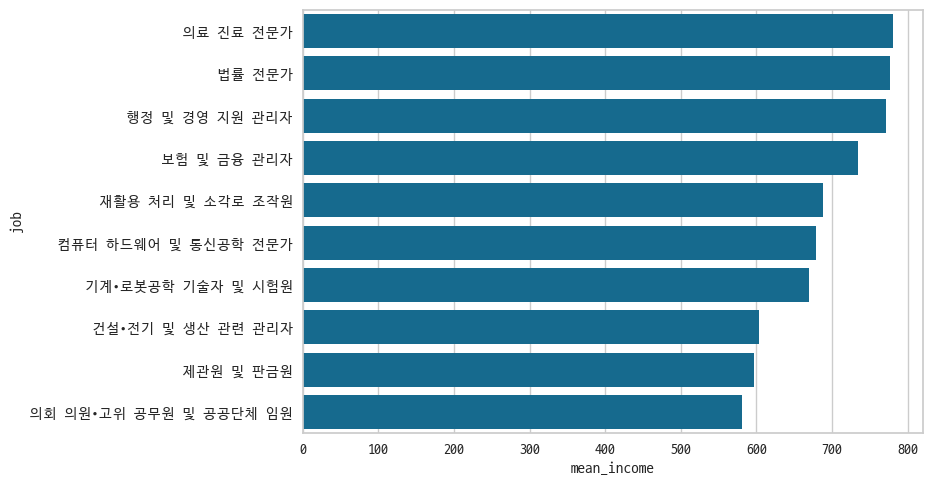

In [125]:
sns.barplot(data=top10, x='mean_income', y='job')

In [126]:
## 평균급여 하위 10개 데이터 추출
bottom10 = job_income.sort_values('mean_income').head(10)
bottom10

,job,mean_income
33,기타 돌봄∙보건 및 개인 생활 서비스 종사자,73.964286
34,기타 서비스 관련 단순 종사자,77.789474
128,청소원 및 환경미화원,88.461756
0,가사 및 육아 도우미,92.455882
43,돌봄 및 보건 서비스 종사자,117.162338
97,음식 관련 단순 종사자,118.187500
39,농림∙어업 관련 단순 종사자,122.625000
126,채굴 및 토목 관련 기능 종사자,140.000000
139,학예사∙사서 및 기록물 관리사,140.000000
135,판매 관련 단순 종사자,140.909091


[(0.0, 800.0)]

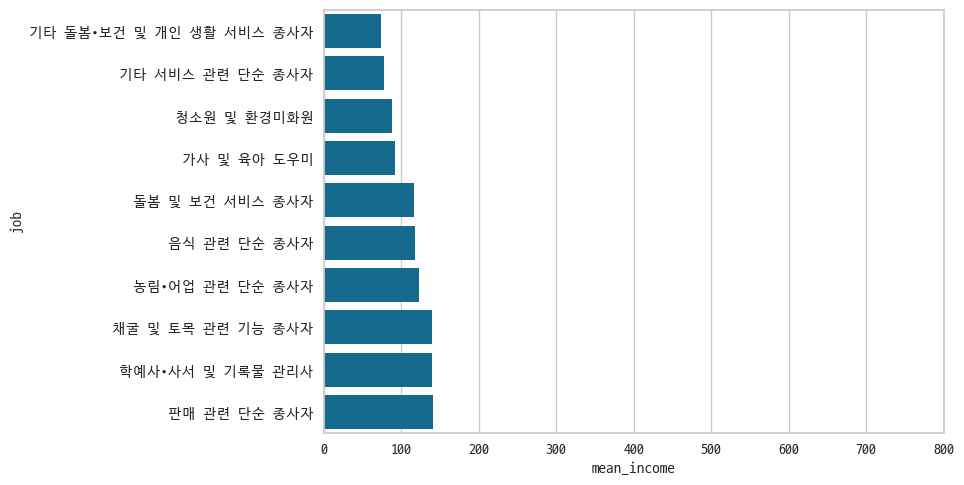

In [127]:
sns.barplot(data=bottom10, x='mean_income', y='job').set(xlim=[0, 800])

## 성별 직종 빈도 - 성별에 따라 어떤 직종이 많을까?

In [128]:
## 남성 직종 빈도 상위 10개 추출
job_male = welfare[welfare['gender'] == 'male'].dropna(subset='job') \
                                               .groupby('job', as_index=False) \
                                               .agg(male_count=('job', 'count')) \
                                               .sort_values('male_count', ascending=False) \
                                               .head(10)
job_male

,job,male_count
107,작물 재배 종사자,486
104,자동차 운전원,230
11,경영 관련 사무원,216
46,매장 판매 종사자,142
89,영업 종사자,113
127,청소원 및 환경미화원,109
4,건설 및 광업 단순 종사자,96
120,제조 관련 단순 종사자,80
3,건물 관리원 및 검표원,79
141,행정 사무원,74


[(0.0, 500.0)]

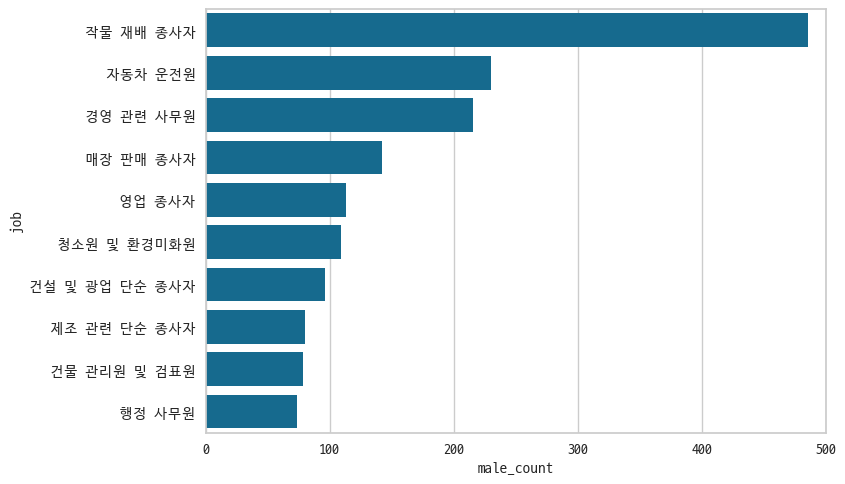

In [129]:
# 남성 직업 빈도 막대 그래프 만들기
sns.barplot(data = job_male, y = 'job', x = 'male_count').set(xlim = [0, 500])

[(0.0, 500.0)]

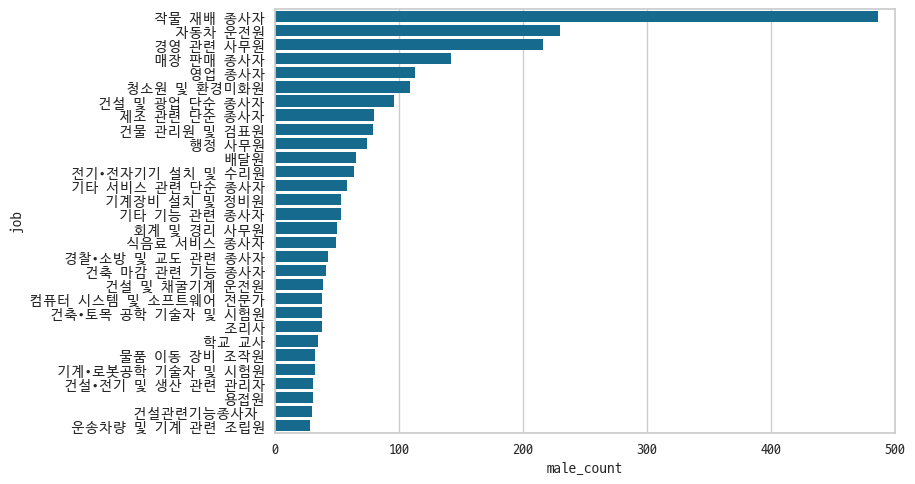

In [134]:
## 남성직업 상위 30개

job_male = welfare[welfare['gender'] == 'male'] \
                  .dropna(subset='job') \
                  .groupby('job', as_index=False) \
                  .agg(male_count=('job', 'count')) \
                  .sort_values('male_count', ascending=False) \
                  .head(30)
                

sns.barplot(data = job_male, y = 'job', x = 'male_count').set(xlim = [0, 500])


In [130]:
## 여성 직종 빈도 상위 10개 추출
job_female = welfare[welfare['gender'] == 'female'].dropna(subset='job') \
                                               .groupby('job', as_index=False) \
                                               .agg(female_count=('job', 'count')) \
                                               .sort_values('female_count', ascending=False) \
                                               .head(10)
job_female 

,job,female_count
83,작물 재배 종사자,476
91,청소원 및 환경미화원,282
33,매장 판매 종사자,212
106,회계 및 경리 사무원,163
31,돌봄 및 보건 서비스 종사자,155
87,제조 관련 단순 종사자,148
73,음식 관련 단순 종사자,126
58,식음료 서비스 종사자,117
88,조리사,114
24,기타 서비스 관련 단순 종사자,97


[(0.0, 500.0)]

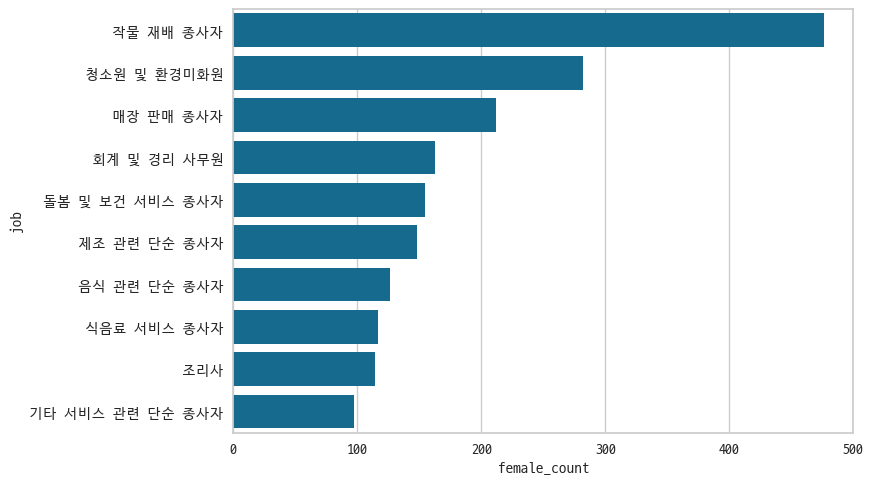

In [131]:
# 여성 직업 빈도 막대 그래프 만들기
sns.barplot(data = job_female, y = 'job', x = 'female_count').set(xlim = [0, 500])

[(0.0, 500.0)]

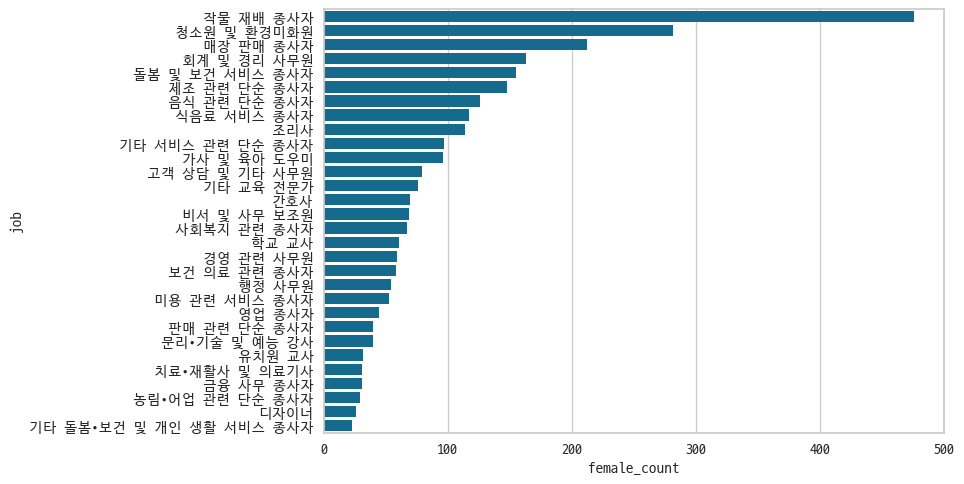

In [133]:
## 여성직업 상위 30개

job_female = welfare[welfare['gender'] == 'female'] \
                  .dropna(subset='job') \
                  .groupby('job', as_index=False) \
                  .agg(female_count=('job', 'count')) \
                  .sort_values('female_count', ascending=False) \
                  .head(30)
                

sns.barplot(data = job_female, y = 'job', x = 'female_count').set(xlim = [0, 500])
